# Senior Project Pipeline: Transform -> Fit -> Compare

*Source project:* `course-files/09-time-series-forecasting/time-series-forecasting/`
(BYU-Idaho senior project, a model-comparison study).

This notebook walks through the senior project's forecasting pipeline end to end:
generate a synthetic daily sales series, run EDA, split with a 3-month holdout,
engineer features, apply transformations, fit five models (Naive, Seasonal Naive,
SARIMA, ETS, XGBoost), and compare them on MAE / RMSE / MAPE.

**Data note.** Every number and plot below comes from the project's own
`synthetic-data-generator.py` (`generate_sample_data`), *not* from the real retail
data the project was actually graded on. The real client demand export and its
scale-shifted derivatives (`retail_data.csv`, `daily_sales.csv`) are private client
data and are never used here. The generator column `Amount` is renamed to `Qty` to
match what the pipeline functions expect.

The pipeline functions below are lifted from
`forecasting-pipeline.py` (the `@st.cache_data` Streamlit decorators and `savefig`
calls are stripped so the notebook runs standalone and plots inline). For SARIMA the
real code searches orders with `pmdarima.auto_arima`; here I fix a small seasonal
order so the notebook runs fast and reproducibly.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import xgboost as xgb
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

RNG = np.random.default_rng(42)
plt.rcParams['figure.dpi'] = 80

## 1. Synthetic data

Adapted from `synthetic-data-generator.py::generate_sample_data`. Three years of
daily data with an upward trend, weekly + yearly seasonality, US-holiday spikes,
noise, ~2% outliers, ~1% missing values, and ~3% irregular gaps.

In [2]:
def generate_sample_data(start_date='2021-01-01', periods=365 * 3):
    """3 years of synthetic daily sales (adapted from synthetic-data-generator.py)."""
    dates = pd.date_range(start=start_date, periods=periods, freq='D')
    df = pd.DataFrame({'Date': dates}).set_index('Date')

    trend = np.linspace(100, 250, periods)                       # upward trend
    dow = df.index.dayofweek
    weekly = np.where(dow < 5, 12, -18)                          # weekday vs weekend
    yearly = 30 * np.sin(2 * np.pi * np.arange(periods) / 365)   # yearly cycle

    holidays = []
    for year in range(df.index.year.min(), df.index.year.max() + 1):
        holidays += [f"{year}-01-01", f"{year}-07-04", f"{year}-12-25"]
        thanksgiving = (pd.Timestamp(f"{year}-11-01")
                        + pd.DateOffset(weekday=3) + pd.DateOffset(weeks=3))
        holidays.append(thanksgiving.strftime('%Y-%m-%d'))
    dstr = df.index.strftime('%Y-%m-%d').values
    holiday_effect = np.zeros(periods)
    for h in holidays:
        idx = np.where(dstr == h)[0]
        if len(idx):
            i0 = idx[0]
            for i in range(-2, 3):
                if 0 <= i0 + i < periods:
                    holiday_effect[i0 + i] += 60 * (1 - abs(i) * 0.3)

    noise = RNG.normal(0, 20, periods)
    df['Qty'] = trend + weekly + yearly + holiday_effect + noise

    outlier_idx = RNG.choice(periods, int(periods * 0.02), replace=False)
    df.iloc[outlier_idx, 0] += (RNG.choice([-1, 1], len(outlier_idx))
                                * RNG.uniform(70, 180, len(outlier_idx)))
    missing_idx = RNG.choice(periods, int(periods * 0.01), replace=False)
    df.iloc[missing_idx, 0] = np.nan
    irregular_idx = RNG.choice(periods, int(periods * 0.03), replace=False)
    df = df.drop(df.index[irregular_idx])
    return df

raw = generate_sample_data()
print("Shape:", raw.shape)
print("Range:", raw.index.min().date(), "to", raw.index.max().date())
print("Missing:", int(raw['Qty'].isna().sum()))
raw.head()

Shape: (1063, 1)
Range: 2021-01-01 to 2023-12-31
Missing: 9


,Qty
Date,
2021-01-01,178.094342
2021-01-02,103.853830
2021-01-03,122.315895
2021-01-04,132.771219
2021-01-05,75.591815


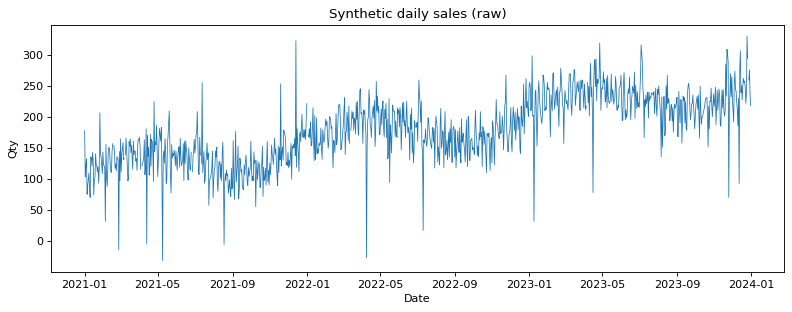

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw.index, raw['Qty'], lw=0.7)
ax.set_title('Synthetic daily sales (raw)')
ax.set_xlabel('Date'); ax.set_ylabel('Qty')
plt.tight_layout(); plt.show()

### Regularize the irregular series

The raw series has missing values and dropped days (irregular spacing). The senior
project's `resampling-utilities.py::resample_time_series` handles exactly this:
reindex onto a regular daily grid and interpolate. Statistical models like SARIMA/ETS
need a regular frequency, so this runs first.

In [4]:
def resample_time_series(df, qty_col='Qty', freq='D', method='linear'):
    '''Regularize + interpolate (adapted from resampling-utilities.py).'''
    regular_index = pd.date_range(df.index.min(), df.index.max(), freq=freq)
    s = df[qty_col].reindex(regular_index).interpolate(method=method)
    out = pd.DataFrame(index=regular_index); out[qty_col] = s
    out.index.name = 'Date'
    return out

df = resample_time_series(raw)
print("After regularizing:", df.shape, "| missing:", int(df['Qty'].isna().sum()))

After regularizing: (1095, 1) | missing: 0


## 2. EDA

`run_eda` in the pipeline runs stationarity tests (ADF, KPSS), a seasonal
decomposition (period=7), and ACF/PACF plots.

In [5]:
print("ADF test p-value:", adfuller(df['Qty'].dropna())[1])
try:
    print("KPSS test p-value:", kpss(df['Qty'].dropna())[1])
except Exception as e:
    print("KPSS failed:", e)

ADF test p-value: 0.7273380276710005
KPSS test p-value: 0.01


/var/folders/2l/wdjbyt6n7197jyn02rh_lqv40000gn/T/ipykernel_30006/2490952347.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print("KPSS test p-value:", kpss(df['Qty'].dropna())[1])


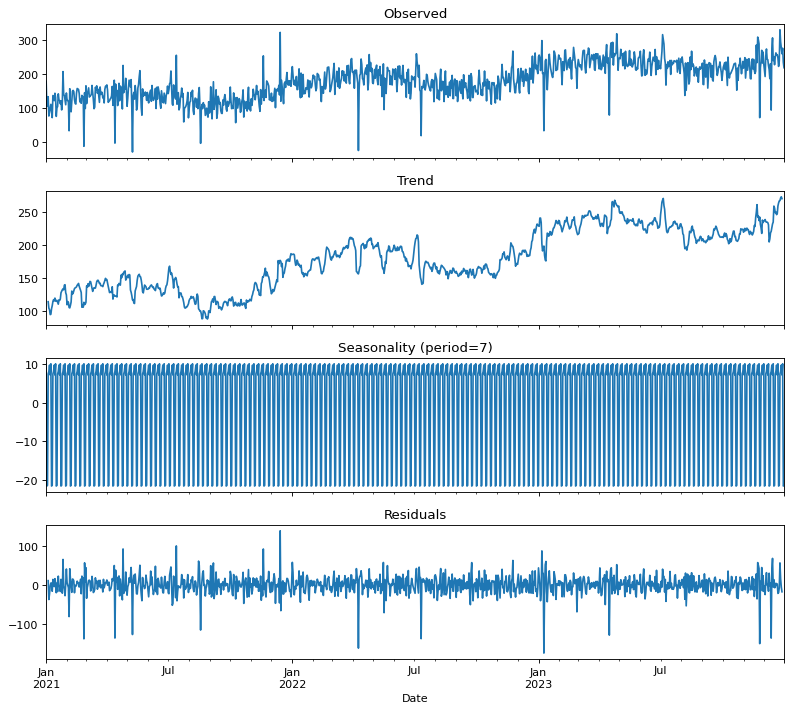

In [6]:
decomp = seasonal_decompose(df['Qty'], model='additive', period=7)
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
decomp.observed.plot(ax=axes[0], title='Observed')
decomp.trend.plot(ax=axes[1], title='Trend')
decomp.seasonal.plot(ax=axes[2], title='Seasonality (period=7)')
decomp.resid.plot(ax=axes[3], title='Residuals')
plt.tight_layout(); plt.show()

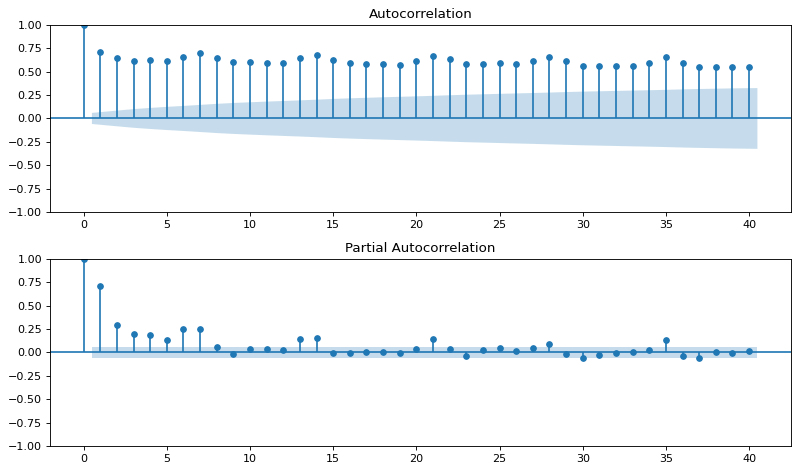

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(df['Qty'].dropna(), lags=40, ax=ax1)
plot_pacf(df['Qty'].dropna(), lags=40, ax=ax2)
plt.tight_layout(); plt.show()

## 3. Train/test split (3-month holdout)

`train_test_split` holds out the last 3 months as the test set, mimicking a real
forecasting scenario where you predict the near future from the past.

Train: 2021-01-01 .. 2023-09-30 (1003)
Test:  2023-10-01 .. 2023-12-31 (92)


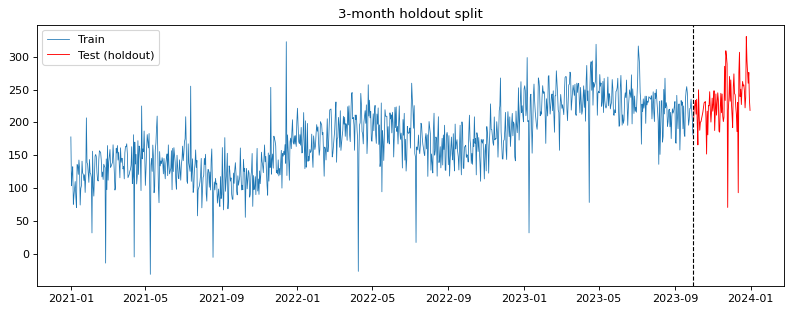

In [8]:
def train_test_split(df, months_holdout=3):
    cutoff = df.index.max() - pd.DateOffset(months=months_holdout)
    train = df[df.index <= cutoff]
    test = df[df.index > cutoff]
    return train, test

train, test = train_test_split(df, months_holdout=3)
print(f"Train: {train.index.min().date()} .. {train.index.max().date()} ({len(train)})")
print(f"Test:  {test.index.min().date()} .. {test.index.max().date()} ({len(test)})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train.index, train['Qty'], label='Train', lw=0.7)
ax.plot(test.index, test['Qty'], label='Test (holdout)', color='red', lw=0.8)
ax.axvline(train.index.max(), color='k', ls='--', lw=1)
ax.set_title('3-month holdout split'); ax.legend()
plt.tight_layout(); plt.show()

## 4. Feature engineering & transformations

`create_features` builds calendar features plus lag_1 / lag_7 and rolling
mean/std over a 7-day window. `apply_transformations` supports log / box-cox /
sqrt / diff with inverse functions.

In [9]:
def create_features(df):
    f = df.copy()
    f['dayofweek'] = f.index.dayofweek
    f['month'] = f.index.month
    f['quarter'] = f.index.quarter
    f['year'] = f.index.year
    f['dayofyear'] = f.index.dayofyear
    f['lag_1'] = f['Qty'].shift(1)
    f['lag_7'] = f['Qty'].shift(7)
    f['rolling_mean_7'] = f['Qty'].rolling(7).mean()
    f['rolling_std_7'] = f['Qty'].rolling(7).std()
    return f.dropna()


def apply_transformations(df, kind=None):
    t = df.copy()
    if kind == 'log':
        t['Qty'] = np.log1p(t['Qty']); inv = np.expm1
    elif kind == 'sqrt':
        t['Qty'] = np.sqrt(t['Qty']); inv = np.square
    elif kind == 'boxcox':
        m = t['Qty'].min()
        if m <= 0: t['Qty'] = t['Qty'] - m + 1
        vals, lam = stats.boxcox(t['Qty'].values); t['Qty'] = vals
        inv = (np.exp if lam == 0
               else (lambda x, lam=lam: np.power(x * lam + 1, 1 / lam)))
    else:
        inv = lambda x: x
    return t, inv

create_features(df).head()

,Qty,dayofweek,month,quarter,year,dayofyear,lag_1,lag_7,rolling_mean_7,rolling_std_7
Date,,,,,,,,,,
2021-01-08,110.241170,4,1,1,2021,8,99.731041,178.094342,104.817983,19.327077
2021-01-09,86.879232,5,1,1,2021,9,110.241170,103.853830,102.393041,20.497651
2021-01-10,70.802390,6,1,1,2021,10,86.879232,122.315895,95.033968,21.380987
2021-01-11,136.097869,0,1,1,2021,11,70.802390,132.771219,95.509204,22.373506
2021-01-12,134.710867,1,1,1,2021,12,136.097869,75.591815,103.954783,24.644864


## 5. Models

Five models matching the project: last-value Naive, Seasonal Naive (same day last
week), SARIMA, ETS (Holt-Winters), and XGBoost. `run_sarima` in the project uses
`auto_arima` to search orders; here a fixed `(1,1,1)(1,1,1,7)` keeps the notebook
fast.

In [10]:
def run_naive(train, test):
    naive = np.array([train['Qty'].iloc[-1]] * len(test))
    seasonal = [train['Qty'].iloc[-(7 + (i % 7))] for i in range(len(test))]
    return naive, np.array(seasonal)


def run_sarima(train, test, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)):
    model = ARIMA(train['Qty'], order=order, seasonal_order=seasonal_order).fit()
    return np.asarray(model.forecast(steps=len(test)))


def run_ets(train, test):
    model = ExponentialSmoothing(train['Qty'], trend=None,
                                 seasonal='add', seasonal_periods=7).fit()
    return np.asarray(model.forecast(len(test)))


def run_xgboost(train_f, test_f):
    drop = ['Qty']
    X_tr = train_f.drop(columns=drop).select_dtypes('number')
    X_te = test_f.drop(columns=drop).select_dtypes('number')
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_tr); Xte = scaler.transform(X_te)
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100,
                             random_state=42)
    model.fit(Xtr, train_f['Qty'])
    return model.predict(Xte)

In [11]:
feat = create_features(df)
train_f = feat[feat.index <= train.index.max()]
test_f = feat[feat.index > train.index.max()]
common_idx = test_f.index                       # feature rows drive the horizon
actual = df.loc[common_idx, 'Qty'].values

naive_fc, snaive_fc = run_naive(train, df.loc[common_idx])
naive_fc = naive_fc[:len(common_idx)]; snaive_fc = snaive_fc[:len(common_idx)]
sarima_fc = run_sarima(train, df.loc[common_idx])[:len(common_idx)]
ets_fc = run_ets(train, df.loc[common_idx])[:len(common_idx)]
xgb_fc = run_xgboost(train_f, test_f)

forecasts = {'Naive': naive_fc, 'Seasonal Naive': snaive_fc,
             'SARIMA': sarima_fc, 'ETS': ets_fc, 'XGBoost': xgb_fc}
print({k: len(v) for k, v in forecasts.items()}, "| actual:", len(actual))

{'Naive': 92, 'Seasonal Naive': 92, 'SARIMA': 92, 'ETS': 92, 'XGBoost': 92} | actual: 92


## 6. Evaluation

`evaluate_forecasts` reports MAE, RMSE, and a zero-safe MAPE.

In [12]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


rows = []
for name, fc in forecasts.items():
    rows.append({'Model': name,
                 'MAE': mean_absolute_error(actual, fc),
                 'RMSE': np.sqrt(mean_squared_error(actual, fc)),
                 'MAPE': mape(actual, fc)})
results = pd.DataFrame(rows).set_index('Model').sort_values('MAE')
results.round(2)

,MAE,RMSE,MAPE
Model,,,
SARIMA,23.61,34.82,12.08
XGBoost,25.69,35.82,12.75
ETS,26.68,37.55,13.11
Seasonal Naive,29.96,40.81,15.47
Naive,52.72,60.98,23.31


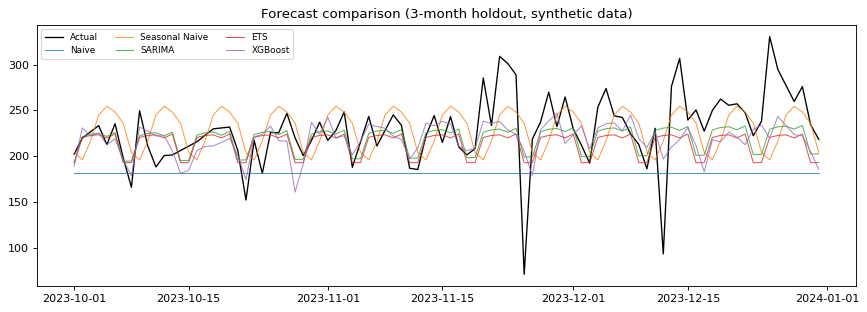

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(common_idx, actual, label='Actual', color='black', lw=1.2)
for name, fc in forecasts.items():
    ax.plot(common_idx, fc, label=name, lw=0.9, alpha=0.8)
ax.set_title('Forecast comparison (3-month holdout, synthetic data)')
ax.legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.show()

## 7. Does transforming help?

The project's `main()` sweeps transformations x models. Here is a small version:
MAE for XGBoost and SARIMA under none / log / sqrt / box-cox transforms. On the real
retail data the takeaway was that transforms *did not* universally help and the
untransformed series often won -- watch whether that holds on this synthetic data.

In [14]:
sweep = {}
for kind in [None, 'log', 'sqrt', 'boxcox']:
    dft, inv = apply_transformations(df, kind)
    tr, te = train_test_split(dft, 3)
    ft = create_features(dft)
    tr_f = ft[ft.index <= tr.index.max()]; te_f = ft[ft.index > tr.index.max()]
    idx = te_f.index; act = df.loc[idx, 'Qty'].values

    xgb_p = inv(run_xgboost(tr_f, te_f))
    sar_p = inv(run_sarima(tr, dft.loc[idx]))[:len(idx)]

    label = kind or 'none'
    sweep[label] = {'XGBoost': mean_absolute_error(act, xgb_p),
                    'SARIMA': mean_absolute_error(act, sar_p)}

pd.DataFrame(sweep).T.round(2)

,XGBoost,SARIMA
none,25.69,23.61
log,23.93,24.04
sqrt,24.60,23.34
boxcox,27.73,30.45


## Takeaways

- The pipeline is a clean **transform -> feature -> fit -> compare** loop; each stage
  is one small function, which is why it promotes cleanly to a notebook.
- On the **real** retail data the project found XGBoost best (MAE 33.67, no transform)
  and Seasonal Naive *worse* than plain Naive (weak weekly seasonality). Results on
  this synthetic series will differ -- the point is the methodology, not the numbers.
- Always compare against the Naive / Seasonal Naive baselines: if a model can't beat
  last-value, it isn't earning its complexity.

*Re-run locally:* `jupyter lab docs/09-time-series-forecasting/notebooks/senior-project-pipeline.ipynb`